# 01 — EDA: HI-Small

Loads via `src/data_loader.py` (source of truth), logs the dataset-stats artifact PLAN.md Phase 1 requires, and produces the figures that make the imbalance and pattern structure visible before any modelling decision is made.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data_loader import dataset_stats, load_accounts, load_config, load_patterns, load_transactions

config = load_config("../config.yaml")
raw_dir = Path("..") / config["paths"]["raw_dir"]
figures_dir = Path("..") / config["paths"]["figures_dir"]
figures_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 110

In [2]:
txns = load_transactions(raw_dir / "HI-Small_Trans.csv")
accounts = load_accounts(raw_dir / "HI-Small_accounts.csv")
patterns = load_patterns(raw_dir / "HI-Small_Patterns.txt")

print(f"transactions: {len(txns):,}")
print(f"accounts:     {len(accounts):,}")
print(f"patterns:     {len(patterns):,}")

transactions: 5,078,345
accounts:     518,581
patterns:     3,209


## Dataset stats — the required first artifact

Row count, class balance, date span, unique accounts. This is the number every later claim gets compared against, so it's logged plainly before anything else.

In [3]:
stats = dataset_stats(txns)
for k, v in stats.items():
    print(f"{k}: {v}")

print(
    f"\nPrevalence: {stats['positive_rate']:.4%} "
    f"({stats['positive_count']:,} laundering / {stats['row_count']:,} total)"
)
print(f"Date span: {(stats['date_max'] - stats['date_min']).days} days")

row_count: 5078345
positive_count: 5177
positive_rate: 0.0010194266045335635
date_min: 2022-09-01 00:00:00
date_max: 2022-09-18 16:18:00
unique_accounts: 515088

Prevalence: 0.1019% (5,177 laundering / 5,078,345 total)
Date span: 17 days


## Class balance

At ~0.1% prevalence, a bar chart on a linear scale is the whole point — it's the single image that justifies every evaluation-metric choice later in the project (why precision@k and PR-AUC, why not accuracy).

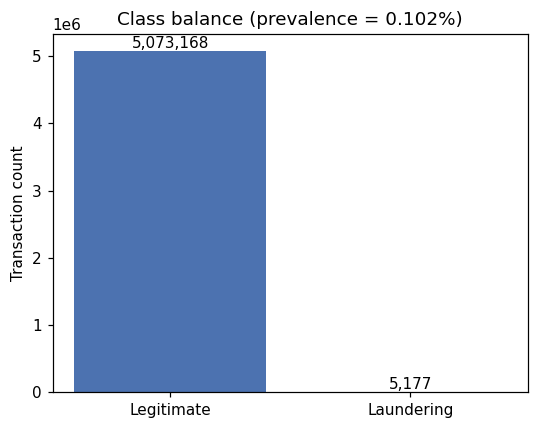

In [4]:
counts = txns["is_laundering"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Legitimate", "Laundering"], counts.values, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Transaction count")
ax.set_title(f"Class balance (prevalence = {stats['positive_rate']:.3%})")
for bar, count in zip(bars, counts.values):
    ax.annotate(f"{count:,}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom")
fig.tight_layout()
fig.savefig(figures_dir / "01_class_balance.png")
plt.show()

## Amount distributions — legitimate vs. laundering (log scale)

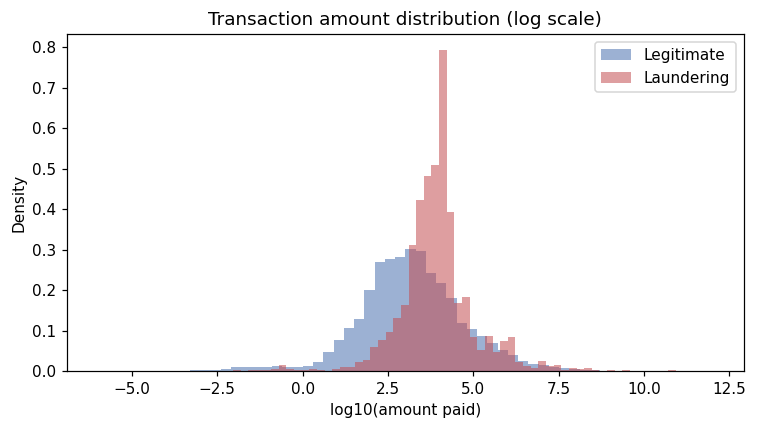

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, name, color in [(0, "Legitimate", "#4C72B0"), (1, "Laundering", "#C44E52")]:
    amounts = txns.loc[txns["is_laundering"] == label, "amount_paid"]
    amounts = amounts[amounts > 0]
    ax.hist(np.log10(amounts), bins=60, alpha=0.55, density=True, label=name, color=color)
ax.set_xlabel("log10(amount paid)")
ax.set_ylabel("Density")
ax.set_title("Transaction amount distribution (log scale)")
ax.legend()
fig.tight_layout()
fig.savefig(figures_dir / "02_amount_distribution.png")
plt.show()

## Transaction volume over time

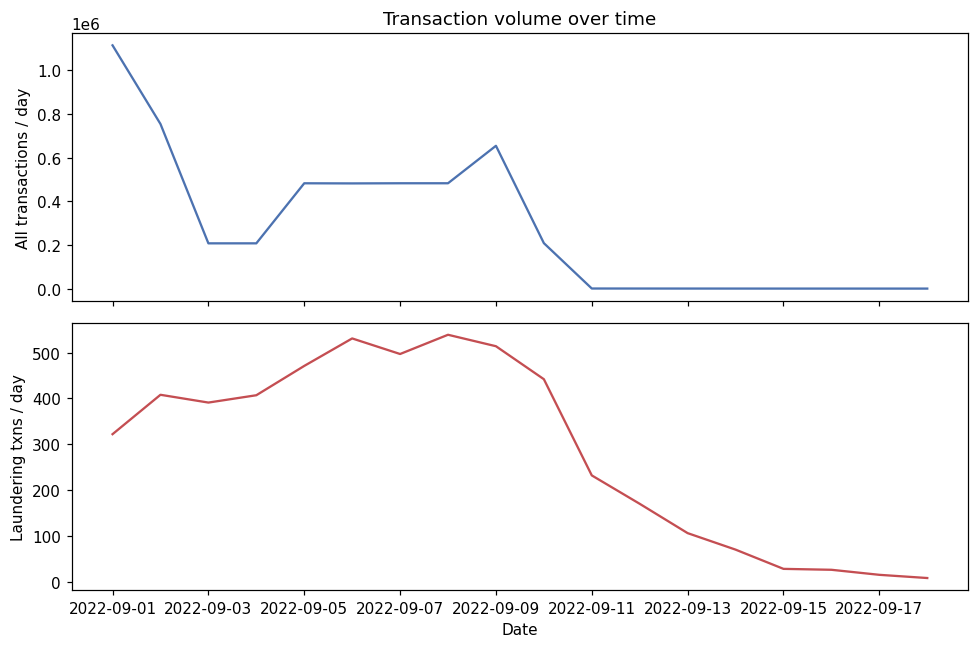

In [6]:
daily = txns.set_index("timestamp").resample("D").agg(
    total=("is_laundering", "size"), laundering=("is_laundering", "sum")
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax1.plot(daily.index, daily["total"], color="#4C72B0")
ax1.set_ylabel("All transactions / day")
ax1.set_title("Transaction volume over time")

ax2.plot(daily.index, daily["laundering"], color="#C44E52")
ax2.set_ylabel("Laundering txns / day")
ax2.set_xlabel("Date")

fig.tight_layout()
fig.savefig(figures_dir / "03_volume_over_time.png")
plt.show()

## Most active accounts

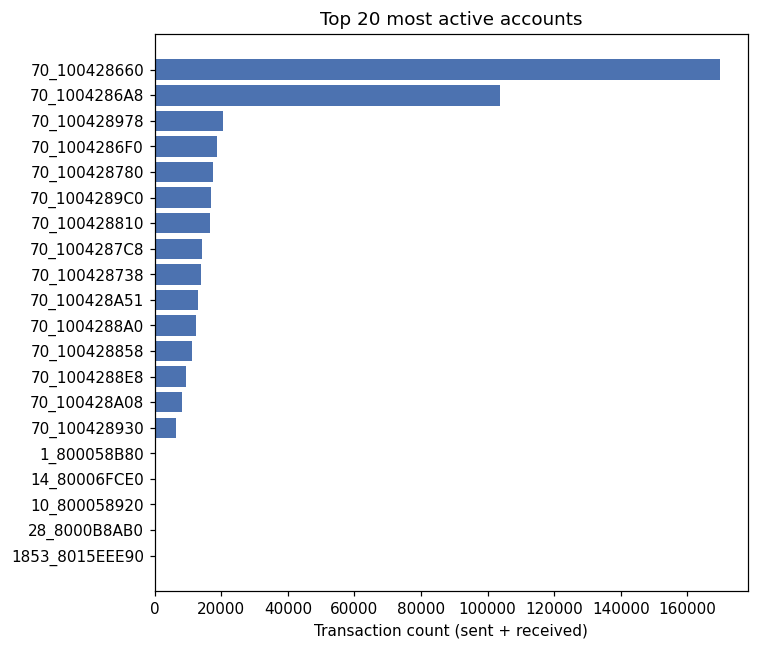

In [7]:
activity = pd.concat([
    txns["from_account_key"].rename("account_key"),
    txns["to_account_key"].rename("account_key"),
]).value_counts().head(20)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(activity.index[::-1], activity.values[::-1], color="#4C72B0")
ax.set_xlabel("Transaction count (sent + received)")
ax.set_title("Top 20 most active accounts")
fig.tight_layout()
fig.savefig(figures_dir / "04_most_active_accounts.png")
plt.show()

## Distribution of the 8 laundering typologies

This is the pattern labelling the brief says to preserve — it drives typology-aware feature engineering (Phase 3) and the recall-per-typology breakdown (Phase 5), and it's a real differentiator versus a generic "detect fraud" project.

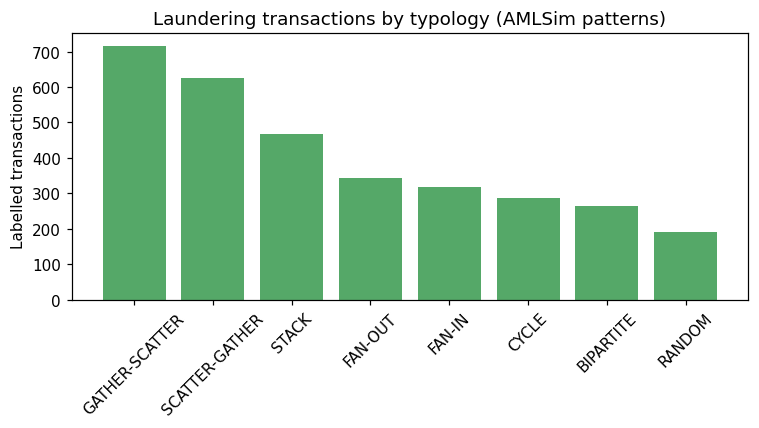

pattern_type
GATHER-SCATTER    716
SCATTER-GATHER    626
STACK             466
FAN-OUT           342
FAN-IN            318
CYCLE             287
BIPARTITE         263
RANDOM            191
Name: count, dtype: int64

3,209 of 5,177 laundering-labelled transactions (62.0%) are attributed to a named typology; the rest are laundering but don't match one of the 8 documented AMLSim patterns.


In [8]:
pattern_counts = patterns["pattern_type"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(pattern_counts.index, pattern_counts.values, color="#55A868")
ax.set_ylabel("Labelled transactions")
ax.set_title("Laundering transactions by typology (AMLSim patterns)")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(figures_dir / "05_typology_distribution.png")
plt.show()

print(pattern_counts)
print(
    f"\n{len(patterns):,} of {stats['positive_count']:,} laundering-labelled transactions "
    f"({len(patterns) / stats['positive_count']:.1%}) are attributed to a named typology; "
    "the rest are laundering but don't match one of the 8 documented AMLSim patterns."
)

## Takeaways carried into later phases

- Prevalence is ~0.1%, not the ~2% the brief estimated — even more extreme imbalance, which strengthens (not weakens) the false-positive-reduction framing.
- The dataset spans only ~18 days, so the 30-day rolling window in `config.yaml` effectively becomes "all history to date" for most transactions — not wrong, just worth knowing when interpreting that feature later.
- Not every laundering transaction is attributed to a named typology; recall-per-typology (Phase 5) will only ever be computed over the subset that is.